# Sentinel‑1 SAR + Sentinel‑2 Optical Fusion Demo (Change Detection with Synthetic Intrusions)

**What this notebook does**

1. Downloads a small **real** Sentinel‑2 (optical) tile and Sentinel‑1 (SAR VV) tile for the same AOI.
2. Creates a **Day‑12** image by injecting synthetic “camp” targets (controlled ground truth) + **cloud occlusion** (optical only) + SAR speckle/noise.
3. Computes **change maps** (optical-only, SAR-only) and a **fused** change probability using a learned logistic fusion.
4. Plots **before / after / change maps / probability maps**, plus **confusion matrices** and **ROC curves**.

> Because we inject targets synthetically, we know the truth and can *tune* difficulty (cloud %, noise, camp size).

In [1]:
# @title Install dependencies (Colab)
!pip -q install pystac-client stackstac rasterio rioxarray shapely pyproj scikit-learn
!pip -q install planetary-computer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 956.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.7 MB/s eta 0:00:00


In [2]:
# @title Imports & small plotting helpers
import os
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import box, mapping
from pystac_client import Client
import planetary_computer
import requests
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
from pyproj import Transformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

np.random.seed(7)

def show_rgb(img, title=None):
    # img: (H,W,3) in [0,1]
    plt.figure(figsize=(6,6))
    plt.imshow(np.clip(img,0,1))
    if title: plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title=None, vmin=None, vmax=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    if title: plt.title(title)
    plt.axis("off")
    plt.show()

def norm_percentile(x, p1=2, p2=98, eps=1e-6):
    lo, hi = np.percentile(x[np.isfinite(x)], [p1, p2])
    y = (x - lo) / (hi - lo + eps)
    return np.clip(y, 0, 1)

def sigmoid(z):
    return 1/(1+np.exp(-z))

In [3]:
# @title Define a small AOI in India (we keep small for speed)
# You can move this box anywhere (small is quich).
min_lon, min_lat = 70.85, 26.55
max_lon, max_lat = 71.05, 26.75
aoi_geom = mapping(box(min_lon, min_lat, max_lon, max_lat))

# Choose a short time window to find acquisitions
date_range = "2024-01-01/2024-12-31"
print("AOI:", (min_lon, min_lat, max_lon, max_lat))
print("Time:", date_range)

AOI: (70.85, 26.55, 71.05, 26.75)
Time: 2024-01-01/2024-12-31


## Satellite data:

### Optical satellite data is useful in defence because it provides high-resolution, human-interpretable imagery similar to what we see with our eyes. It helps identify vehicles, aircraft, ships, infrastructure, roads, and terrain features clearly. Optical imagery is especially powerful for object recognition, damage assessment, and mapping urban or border areas. With infrared bands, it can also detect heat signatures for limited night surveillance. However, it depends on daylight and clear weather conditions.

### SAR (Synthetic Aperture Radar) is extremely valuable because it is an active sensor — it sends its own microwave signals and works day and night, in all weather conditions. It can see through clouds, smoke, and light vegetation, making it ideal for persistent surveillance. SAR is highly effective for ship detection, flood mapping, change detection (like new bunker or road construction), and monitoring terrain deformation. It also responds strongly to metallic objects, which helps in detecting vehicles and military hardware.

### Together, optical and SAR data complement each other. Optical provides detailed vsual information, while SAR ensures 24×7, all-weather monitoring. In defence applications, combining both reduces uncertainty, improves target confirmation, and enhances situational awareness through multi-sensor fusion — which is central to modern GeoAI-driven military intelligence systems.

Using Sentinel‑2: S2A_42RYQ_20241225_0_L2A cloud_cover: 0.004778
Downloading: s2_red.tif
Downloading: s2_green.tif
Downloading: s2_blue.tif
Downloading: s2_nir.tif
Using Sentinel‑1: S1A_IW_GRDH_1SDV_20241228T131951_20241228T132016_057193_07089E
Downloading: s1_vv.tif
Cropped S2 (4 bands) shape: (4, 2246, 391)
S1 reprojected shape: (2246, 391)


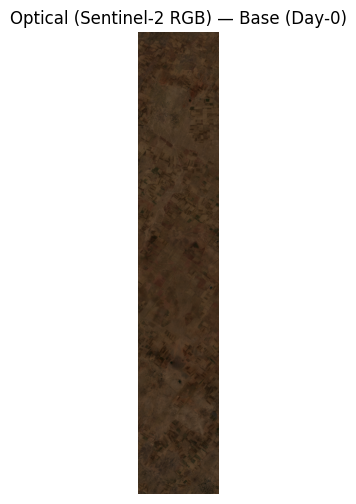

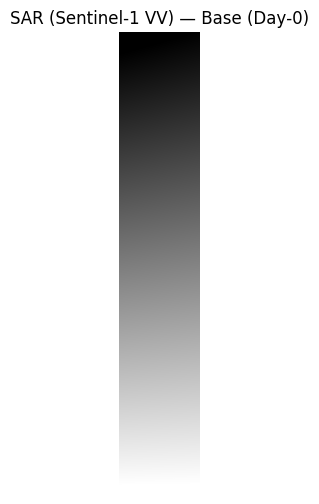

In [4]:
# @title Download & crop Sentinel‑2 (RGB+NIR) and Sentinel‑1 (VV) to the same grid

# ---- Public access settings (important on Colab) ----
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif"

# ---- Helpers ----
def download_asset(asset_url, filename):
    if os.path.exists(filename) and os.path.getsize(filename) > 0:
        return
    print("Downloading:", filename)
    r = requests.get(asset_url, stream=True, timeout=120)
    r.raise_for_status()
    with open(filename, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)

# ---- 1) Sentinel‑2 from AWS Earth Search ----
es_client = Client.open("https://earth-search.aws.element84.com/v1")
s2_search = es_client.search(
    collections=["sentinel-2-l2a"],
    intersects=aoi_geom,
    datetime=date_range,
    query={"eo:cloud_cover": {"lt": 20}},
    max_items=5,
)
s2_items = list(s2_search.items())
assert len(s2_items) > 0, "No Sentinel‑2 items found. Try widening AOI or date_range."
s2 = sorted(s2_items, key=lambda x: x.properties.get("eo:cloud_cover", 100))[0]
print("Using Sentinel‑2:", s2.id, "cloud_cover:", s2.properties.get("eo:cloud_cover"))

# bands: red/green/blue/nir (COGs)
s2_band_keys = ["red", "green", "blue", "nir"]
s2_files = {}
for band in s2_band_keys:
    url = s2.assets[band].href
    fname = f"s2_{band}.tif"
    download_asset(url, fname)
    s2_files[band] = fname

# ---- 2) Sentinel‑1 from Planetary Computer (signed) ----
pc_client = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
s1_search = pc_client.search(
    collections=["sentinel-1-grd"],
    intersects=aoi_geom,
    datetime=date_range,
    max_items=8,
)
s1_items = list(s1_search.items())
assert len(s1_items) > 0, "No Sentinel‑1 items found. Try widening AOI or date_range."

s1 = None
for item in s1_items:
    if "vv" in item.assets:
        s1 = planetary_computer.sign(item)
        break
assert s1 is not None, "No Sentinel‑1 VV asset found in returned items."
print("Using Sentinel‑1:", s1.id)

download_asset(s1.assets["vv"].href, "s1_vv.tif")

# ---- 3) Crop S2 to AOI in its CRS, keep crop grid transform ----
s2_stack = []
for band in s2_band_keys:
    with rasterio.open(s2_files[band]) as src:
        transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
        left, bottom = transformer.transform(min_lon, min_lat)
        right, top   = transformer.transform(max_lon, max_lat)
        win = from_bounds(left, bottom, right, top, src.transform)
        arr = src.read(1, window=win).astype("float32")
        s2_stack.append(arr)

s2_img = np.stack(s2_stack, axis=0).astype("float32")  # (4,H,W)
print("Cropped S2 (4 bands) shape:", s2_img.shape)

with rasterio.open(s2_files["red"]) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    left, bottom = transformer.transform(min_lon, min_lat)
    right, top   = transformer.transform(max_lon, max_lat)
    win = from_bounds(left, bottom, right, top, src.transform)
    s2_crop_transform = src.window_transform(win)
    s2_crop_crs = src.crs
    H, W = s2_img.shape[1], s2_img.shape[2]

# ---- 4) Reproject S1 VV onto the S2 crop grid ----
with rasterio.open("s1_vv.tif") as src:
    src_crs = src.crs if src.crs is not None else "EPSG:4326"
    vv_full = src.read(1).astype("float32")
    vv_on_s2 = np.zeros((H, W), dtype="float32")

    reproject(
        source=vv_full,
        destination=vv_on_s2,
        src_transform=src.transform,
        src_crs=src_crs,
        dst_transform=s2_crop_transform,
        dst_crs=s2_crop_crs,
        resampling=Resampling.bilinear,
    )

vv = vv_on_s2  # (H,W)
print("S1 reprojected shape:", vv.shape)

# ---- 5) Normalize to look like images ----
# Sentinel‑2 reflectance is typically scaled ~0..10000
s2_norm = np.clip(s2_img / 10000.0, 0, 1)  # (4,H,W)
rgb_base = np.stack([s2_norm[0], s2_norm[1], s2_norm[2]], axis=-1)  # (H,W,3)

# SAR often has heavy tails; normalize by percentiles
sar_base = norm_percentile(vv)

show_rgb(rgb_base, "Optical (Sentinel‑2 RGB) — Base (Day‑0)")
show_gray(sar_base, "SAR (Sentinel‑1 VV) — Base (Day‑0)")

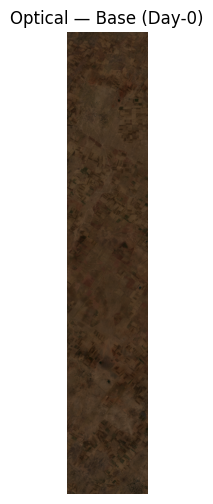

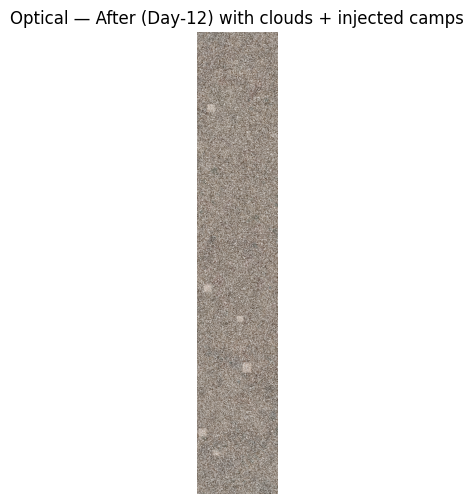

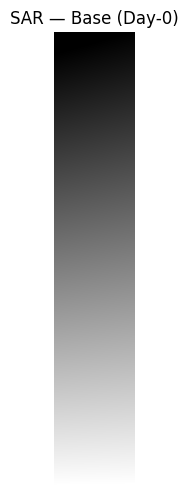

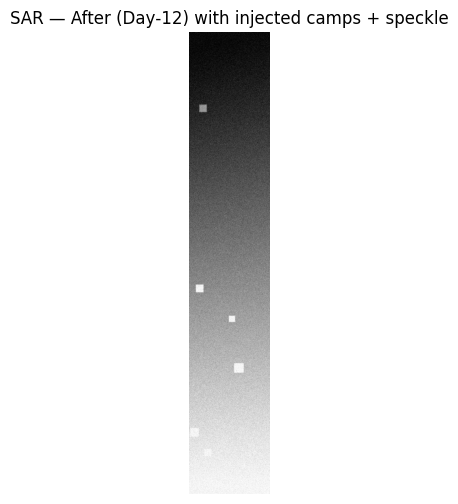

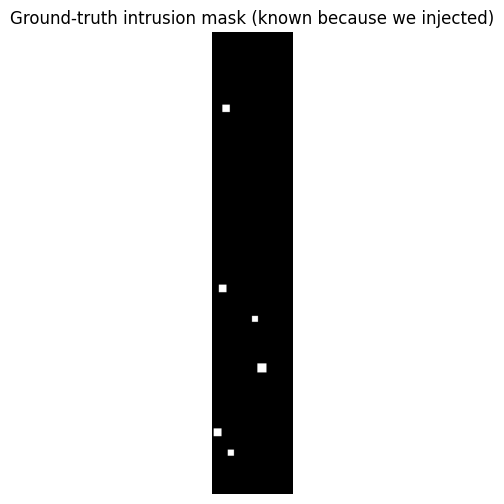

Intrusion pixels: 7786 out of 878186 (0.89%)


In [5]:
# @title Create Day‑12 "after" imagery by injecting synthetic camps + clouds + SAR speckle (ground truth known)

H, W = sar_base.shape

# ---- knobs you can tune (controls accuracy) ----
N_CAMPS = 6
CAMP_SIZE_RANGE = (18, 40)     # pixels
OPTICAL_BRIGHT_BOOST = 0.30    # tents brighten RGB
SAR_BOOST = 0.45               # vehicles/metal spike in SAR
CLOUD_FRACTION = 0.45          # optical occlusion
SAR_NOISE_STD = 0.10           # speckle/noise in SAR
EDGE_SOFTEN = True             # makes camps look more "real"

rgb_after = rgb_base.copy()
sar_after = sar_base.copy()

gt_mask = np.zeros((H, W), dtype=np.uint8)

def soft_square(mask, x0, y0, s, softness=3):
    # draw square with a soft border (simple distance fade)
    x1, y1 = x0 + s, y0 + s
    x0c, x1c = max(0,x0), min(H,x1)
    y0c, y1c = max(0,y0), min(W,y1)
    mask[x0c:x1c, y0c:y1c] = 1
    if softness > 0:
        # expand and fade
        for k in range(1, softness+1):
            val = max(1 - k/(softness+1), 0)
            xs0, xs1 = max(0, x0-k), min(H, x1+k)
            ys0, ys1 = max(0, y0-k), min(W, y1+k)
            mask[xs0:xs1, ys0:ys1] = np.maximum(mask[xs0:xs1, ys0:ys1], val)

# ---- inject camps ----
for _ in range(N_CAMPS):
    s = np.random.randint(CAMP_SIZE_RANGE[0], CAMP_SIZE_RANGE[1]+1)
    x0 = np.random.randint(10, H - s - 10)
    y0 = np.random.randint(10, W - s - 10)

    local = np.zeros((H,W), dtype=float)
    if EDGE_SOFTEN:
        soft_square(local, x0, y0, s, softness=4)
    else:
        local[x0:x0+s, y0:y0+s] = 1.0

    # ground truth
    gt_mask = np.maximum(gt_mask, (local > 0.5).astype(np.uint8))

    # optical: brighten like tents / disturbed soil
    rgb_after[..., 0] = np.clip(rgb_after[..., 0] + OPTICAL_BRIGHT_BOOST * local, 0, 1)
    rgb_after[..., 1] = np.clip(rgb_after[..., 1] + OPTICAL_BRIGHT_BOOST * local, 0, 1)
    rgb_after[..., 2] = np.clip(rgb_after[..., 2] + OPTICAL_BRIGHT_BOOST * local, 0, 1)

    # SAR: strong backscatter spike
    sar_after = np.clip(sar_after + SAR_BOOST * local, 0, 1)

# ---- add clouds to optical AFTER only ----
cloud_mask = (np.random.rand(H, W) < CLOUD_FRACTION)
rgb_after[cloud_mask] = 1.0  # white clouds

# ---- add SAR speckle/noise ----
sar_after = np.clip(sar_after + np.random.normal(0, SAR_NOISE_STD, size=(H,W)), 0, 1)

# ---- quick visuals ----
show_rgb(rgb_base,  "Optical — Base (Day‑0)")
show_rgb(rgb_after, "Optical — After (Day‑12) with clouds + injected camps")

show_gray(sar_base,  "SAR — Base (Day‑0)")
show_gray(sar_after, "SAR — After (Day‑12) with injected camps + speckle")

show_gray(gt_mask, "Ground‑truth intrusion mask (known because we injected)", vmin=0, vmax=1)

print("Intrusion pixels:", int(gt_mask.sum()), "out of", H*W, f"({100*gt_mask.mean():.2f}%)")

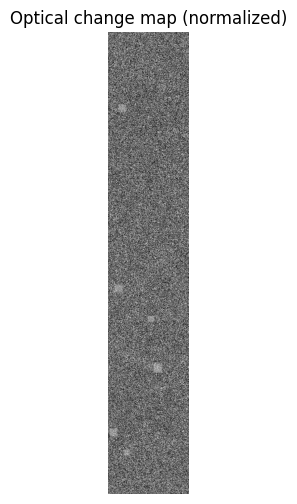

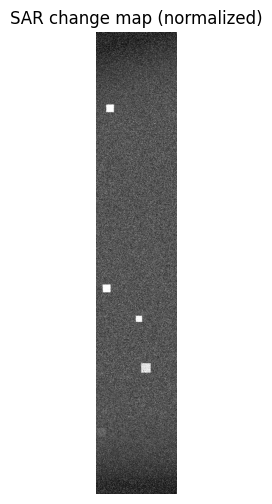

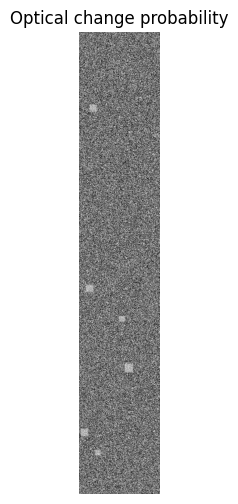

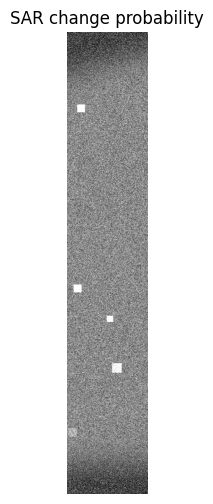

In [6]:
# @title Compute change maps (optical-only vs SAR-only) and plot

# Change maps (0..1)
opt_change = np.mean(np.abs(rgb_after - rgb_base), axis=2)
sar_change = np.abs(sar_after - sar_base)

# Normalize change maps to [0,1] robustly
opt_change_n = norm_percentile(opt_change)
sar_change_n = norm_percentile(sar_change)

show_gray(opt_change_n, "Optical change map (normalized)")
show_gray(sar_change_n, "SAR change map (normalized)")

# Turn change maps into "detection probabilities"
# (sigmoid on shifted/scaled change — simple but effective for teaching)
opt_probs = sigmoid(10 * (opt_change_n - 0.35))
sar_probs = sigmoid(10 * (sar_change_n - 0.25))

show_gray(opt_probs, "Optical change probability")
show_gray(sar_probs, "SAR change probability")

Optical accuracy: 0.5487
SAR accuracy:     0.4862


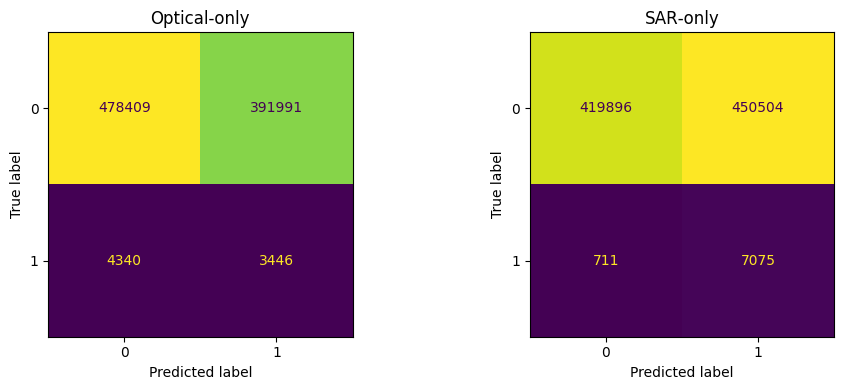

In [7]:
# @title Evaluate optical-only and SAR-only detectors (threshold = 0.5)

y_true = gt_mask.flatten().astype(int)

opt_pred = (opt_probs.flatten() > 0.5).astype(int)
sar_pred = (sar_probs.flatten() > 0.5).astype(int)

opt_acc = accuracy_score(y_true, opt_pred)
sar_acc = accuracy_score(y_true, sar_pred)

print("Optical accuracy:", round(opt_acc,4))
print("SAR accuracy:    ", round(sar_acc,4))

# Confusion matrices
fig, axs = plt.subplots(1, 2, figsize=(10,4))
for ax, preds, title in zip(axs, [opt_pred, sar_pred], ["Optical‑only", "SAR‑only"]):
    cm = confusion_matrix(y_true, preds)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

Fusion accuracy: 0.8146
Learned weights (SAR, Optical): [[0.45  0.105]]
Bias: [-1.429]


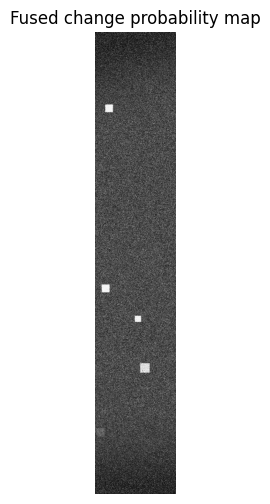

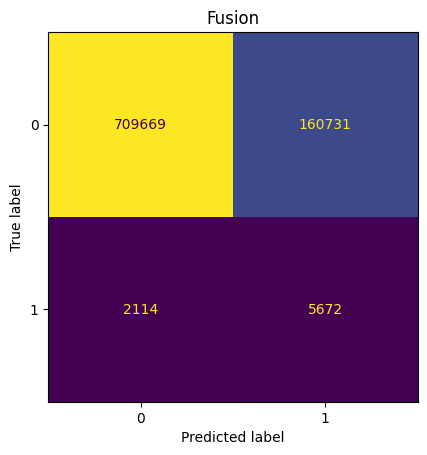

In [10]:
# @title Learned Logistic Fusion (stacking SAR + Optical) + plots

from scipy.special import logit

# features = logits of the per-pixel probabilities
X = np.vstack([logit(sar_probs.flatten().clip(1e-4, 1-1e-4)),
               logit(opt_probs.flatten().clip(1e-4, 1-1e-4))]).T

clf = LogisticRegression(max_iter=200, class_weight="balanced")
clf.fit(X, y_true)

fused_probs = clf.predict_proba(X)[:, 1].reshape(H, W)
fused_pred  = (fused_probs.flatten() > 0.5).astype(int)

fusion_acc = accuracy_score(y_true, fused_pred)
print("Fusion accuracy:", round(fusion_acc,4))
print("Learned weights (SAR, Optical):", clf.coef_.round(3))
print("Bias:", clf.intercept_.round(3))

show_gray(fused_probs, "Fused change probability map")

# Confusion matrix
cm = confusion_matrix(y_true, fused_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(colorbar=False)
plt.title("Fusion")
plt.show()

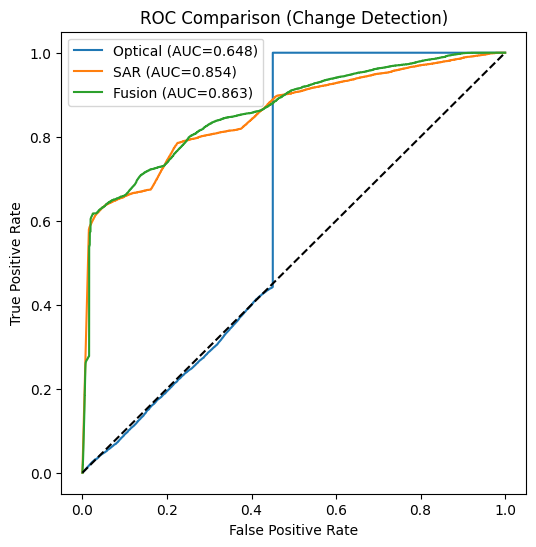

In [11]:
# @title ROC Curves: Optical vs SAR vs Fusion

fpr_o, tpr_o, _ = roc_curve(y_true, opt_probs.flatten())
fpr_s, tpr_s, _ = roc_curve(y_true, sar_probs.flatten())
fpr_f, tpr_f, _ = roc_curve(y_true, fused_probs.flatten())

auc_o = auc(fpr_o, tpr_o)
auc_s = auc(fpr_s, tpr_s)
auc_f = auc(fpr_f, tpr_f)

plt.figure(figsize=(6,6))
plt.plot(fpr_o, tpr_o, label=f"Optical (AUC={auc_o:.3f})")
plt.plot(fpr_s, tpr_s, label=f"SAR (AUC={auc_s:.3f})")
plt.plot(fpr_f, tpr_f, label=f"Fusion (AUC={auc_f:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Change Detection)")
plt.legend()
plt.show()

## Summary:
- **Base vs After**: “Same area, 12 days later. Optical is partly blind due to clouds; SAR still sees structure.”
- **Ground truth**: “We injected the targets, so we know exactly where they are — that’s how we can measure accuracy.”
- **Optical change map**: “Cloud edges create false alarms; some camps are missed under full cloud cover.”
- **SAR change map**: “SAR sees camps through clouds but adds speckle/noise — still better coverage.”
- **Fusion**: “The model learns how to weight sensors; it trusts SAR more under cloud-induced uncertainty.”
- **ROC**: “Fusion pushes the curve up/left: fewer false alarms at the same detection rate.”